In [1]:
import json
import os
import random

import h5py
import numpy as np

import time
%matplotlib inline
import matplotlib.pyplot as plt

import robosuite
import imageio
from pprint import pprint   
from lxml import etree

In [2]:
dataset_type = 'ph'

In [3]:
demo_path = f"data/demonstrations/can/{dataset_type}"
hdf5_path = os.path.join(demo_path, f"new_env_demo_{dataset_type}.hdf5")
# hdf5_path = "processed_dataset/new_dataset_ph.hdf5"
f = h5py.File(hdf5_path, "r")
# env_name = f["data"].attrs["env"]
env_name ="PickPlaceCansMilk"
env_info = json.loads(f["data"].attrs["env_info"])
env_info['camera_names'] = ['frontview', 'birdview', 'agentview', 'robot0_eye_in_hand']
# env_info["camera_names"] = "frontview"
env_info["has_renderer"] = False
env_info["use_camera_obs"] = True
env_info["ignore_done"] = True
env_info["has_offscreen_renderer"] = True
env_info["camera_heights"] = 1024
env_info["camera_widths"] = 1024

In [4]:
env = robosuite.make(env_name, **env_info)

# list of all demonstrations episodes
demos = list(f["data"].keys())

# print("Playing back random episode... (press ESC to quit)")

i = 0
ep = demos[i]
# ep = "demo_2"
# os.path.exists(ep) or os.makedirs(ep)
env.reset()

# read the model xml, using the metadata stored in the attribute for this episode
# model_xml = f["data/{}".format(ep)].attrs["model_file"]

# env.reset()
# xml = env.edit_model_xml(model_xml)
# env.reset_from_xml_string(xml)
# env.sim.reset()

states = f["data/{}/states".format(ep)][()]

# load the actions and play them back open-loop
actions = np.array(f["data/{}/actions".format(ep)][()])

# find obj_to_use
env.sim.set_state_from_flattened(states[-2])
env.step(actions[-1])
obj_id = np.where(env.objects_in_bins==1)[0][0]
obj_to_use = env.objects[obj_id]
obj_name = env.obj_names[obj_id]

env.sim.set_state_from_flattened(states[0])
env.sim.forward()

num_actions = actions.shape[0]
keyframes = []
keyframe_infos = []


In [5]:
collisions = 0
prev_image = None
same = True
for state in states:
    env.sim.set_state_from_flattened(state)
    env.sim.forward()
    # env.sim.step()
    env._update_observables()
    # # Pos
    # obj_geom_id = list(env.obj_geom_id.values())[obj_id][0]
    # print(env.sim.data.geom_xpos[obj_geom_id])
    # # contacts
    # contacts = env.get_contacts(obj_to_use)
    # print(contacts)
    if prev_image is not None:
        same = same and np.all(np.equal(env._get_observations()['frontview_image'], prev_image))
    # print(env._get_observations()['frontview_image'])
    prev_image = env._get_observations()['frontview_image']
same

False

In [6]:
env.sim.model._geom_id2name.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121])

In [7]:
env._observables

OrderedDict([('robot0_joint_pos',
              <robosuite.utils.observables.Observable at 0x7fc7734ca410>),
             ('robot0_joint_pos_cos',
              <robosuite.utils.observables.Observable at 0x7fc7fd198810>),
             ('robot0_joint_pos_sin',
              <robosuite.utils.observables.Observable at 0x7fc7a696e190>),
             ('robot0_joint_vel',
              <robosuite.utils.observables.Observable at 0x7fc7a696e590>),
             ('robot0_eef_pos',
              <robosuite.utils.observables.Observable at 0x7fc7730809d0>),
             ('robot0_eef_quat',
              <robosuite.utils.observables.Observable at 0x7fc773080a10>),
             ('robot0_eef_vel_lin',
              <robosuite.utils.observables.Observable at 0x7fc7fd1987d0>),
             ('robot0_eef_vel_ang',
              <robosuite.utils.observables.Observable at 0x7fc773080a50>),
             ('robot0_gripper_qpos',
              <robosuite.utils.observables.Observable at 0x7fc773080a90>),
       

In [8]:
env.obj_names[obj_id]

'Milk'

In [9]:
print('\n'.join(env._observables.keys()))

robot0_joint_pos
robot0_joint_pos_cos
robot0_joint_pos_sin
robot0_joint_vel
robot0_eef_pos
robot0_eef_quat
robot0_eef_vel_lin
robot0_eef_vel_ang
robot0_gripper_qpos
robot0_gripper_qvel
frontview_image
birdview_image
agentview_image
robot0_eye_in_hand_image
world_pose_in_gripper
Milk_pos
Milk_quat
Milk_to_robot0_eef_pos
Milk_to_robot0_eef_quat
Bread_pos
Bread_quat
Bread_to_robot0_eef_pos
Bread_to_robot0_eef_quat
Cereal_pos
Cereal_quat
Cereal_to_robot0_eef_pos
Cereal_to_robot0_eef_quat
Can_pos
Can_quat
Can_to_robot0_eef_pos
Can_to_robot0_eef_quat
Lemon_pos
Lemon_quat
Lemon_to_robot0_eef_pos
Lemon_to_robot0_eef_quat
Bottle_pos
Bottle_quat
Bottle_to_robot0_eef_pos
Bottle_to_robot0_eef_quat


In [39]:
f.close()


In [40]:
env.close()

## Contact force

In [39]:
from robosuite.models.base import MujocoModel

def get_contact_force(sim, model):
    assert isinstance(model, MujocoModel)
    contact_set = env.get_contacts(model)
    for i, contact in sim.data.contact[: sim.data.ncon]:
        print(contact.cfrc_ext)

In [51]:
env.obj_body_id

{'Milk': 24, 'Bread': 25, 'Cereal': 26, 'Can': 27, 'Lemon': 28, 'Bottle': 29}

In [53]:
env.obj_geom_id

{'Milk': [110],
 'Bread': [112],
 'Cereal': [114],
 'Can': [116],
 'Lemon': [118],
 'Bottle': [120]}

In [52]:
env.sim.data.body_xpos[24]

array([0.15877913, 0.17732197, 0.8600588 ])

In [56]:
env.sim.model._body_id2name

{0: 'world',
 1: 'bin1',
 2: 'bin2',
 3: 'robot0_base',
 4: 'robot0_link0',
 5: 'robot0_link1',
 6: 'robot0_link2',
 7: 'robot0_link3',
 8: 'robot0_link4',
 9: 'robot0_link5',
 10: 'robot0_link6',
 11: 'robot0_link7',
 12: 'robot0_right_hand',
 13: 'gripper0_right_gripper',
 14: 'gripper0_eef',
 15: 'gripper0_leftfinger',
 16: 'gripper0_finger_joint1_tip',
 17: 'gripper0_rightfinger',
 18: 'gripper0_finger_joint2_tip',
 19: 'mount0_base',
 20: 'mount0_controller_box',
 21: 'mount0_pedestal_feet',
 22: 'mount0_torso',
 23: 'mount0_pedestal',
 24: 'Milk_main',
 25: 'Bread_main',
 26: 'Cereal_main',
 27: 'Can_main',
 28: 'Lemon_main',
 29: 'Bottle_main'}

In [50]:
env.sim.data.body

<bound method PyCapsule.body of <mujoco._structs.MjData object at 0x7f40ced3fd30>>

In [43]:
env.get_contacts(env.objects[env.object_id])
for contact in env.sim.data.contact[: env.sim.data.ncon]:
    print(contact.efc_address)

10
14
18
22
26
30


In [38]:
for state in states:
    env.sim.set_state_from_flattened(state)
    env.sim.forward()
    # env.sim.step()
    env._update_observables()
    if env.sim.data.ncon != 6:
        print(env.sim.data.ncon, env.sim.data.cfrc_ext.shape)

7 (30, 6)
8 (30, 6)
8 (30, 6)
8 (30, 6)
10 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
10 (30, 6)
9 (30, 6)
10 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
10 (30, 6)
10 (30, 6)
10 (30, 6)
10 (30, 6)
8 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
9 (30, 6)
5 (30, 6)
5 (30, 6)
5 (30, 6)


## Distance

In [23]:
env.obj_geom_id

{'Milk': [110],
 'Bread': [112],
 'Cereal': [114],
 'Can': [116],
 'Lemon': [118],
 'Bottle': [120]}

In [24]:
env.sim.data.geom_xpos[110]

array([0.15876858, 0.17717625, 0.86041719])

In [ ]:
env.bin1_pos, env.bin2_pos

array([0.1 , 0.28, 0.8 ])

In [ ]:
env.bin_size

array([0.39, 0.49, 0.82])

In [ ]:
for i in range(7, 17):
    print(i, env.sim.data.geom_xpos[i])

7 [ 0.1  -0.25  0.8 ]
8 [ 0.1  -0.25  0.8 ]
9 [0.1  0.   0.85]
10 [0.1  0.   0.85]
11 [ 0.1  -0.5   0.85]
12 [ 0.1  -0.5   0.85]
13 [ 0.3  -0.25  0.85]
14 [ 0.3  -0.25  0.85]
15 [-0.1  -0.25  0.85]
16 [-0.1  -0.25  0.85]


In [ ]:
for i in range(21, 35):
    print(i, env.sim.data.geom_xpos[i])

21 [0.1  0.28 0.8 ]
22 [0.1  0.28 0.8 ]
23 [0.1  0.53 0.85]
24 [0.1  0.53 0.85]
25 [0.1  0.28 0.85]
26 [0.1  0.28 0.85]
27 [0.1  0.03 0.85]
28 [0.1  0.03 0.85]
29 [0.3  0.28 0.85]
30 [0.3  0.28 0.85]
31 [0.1  0.28 0.85]
32 [0.1  0.28 0.85]
33 [-0.1   0.28  0.85]
34 [-0.1   0.28  0.85]


In [ ]:
env.sim.data.geom_xpos[7], env.sim.data.geom_xpos[21]

(array([ 0.1 , -0.25,  0.8 ]), array([0.1 , 0.28, 0.8 ]))

In [ ]:
for j, action in enumerate(actions):
    obs, reward, done, info = env.step(action)

    obj_geom_id = list(env.obj_geom_id.values())[obj_id][0]
    print(env.sim.data.geom_xpos[obj_geom_id])

    if j < num_actions - 1:
        # ensure that the actions deterministically lead to the same recorded states
        state_playback = env.sim.get_state().flatten()
        state_data = states[j + 1]
        if not np.all(np.equal(state_data, state_playback)):
            err = np.linalg.norm(state_data - state_playback)
            # if err > 2:
            #     print("State mismatch in demo {} at step {}! Error: {}".format(ep, j, err))
            #     break
            # print(f"[warning] playback diverged by {err:.2f} for ep {ep} at step {j}")

[ 0.11122177 -0.21756416  0.86040493]
[ 0.11121268 -0.21757465  0.86040768]
[ 0.11122034 -0.21756338  0.86040963]
[ 0.11123176 -0.21756777  0.86041437]
[ 0.11123936 -0.21757273  0.86040684]
[ 0.11121131 -0.21757966  0.86040739]
[ 0.11120132 -0.21757811  0.86040883]
[ 0.11124176 -0.21758652  0.86040999]
[ 0.1112469  -0.2175935   0.86040966]
[ 0.11122955 -0.2175567   0.86041145]
[ 0.11123081 -0.21755635  0.86041447]
[ 0.11120685 -0.21759053  0.86041197]
[ 0.11124386 -0.21757724  0.86041136]
[ 0.11121438 -0.21759268  0.8604117 ]
[ 0.11124648 -0.21758705  0.86040948]
[ 0.11124976 -0.21755467  0.86041306]
[ 0.11126383 -0.21758944  0.86041523]
[ 0.11125142 -0.21757189  0.86041417]
[ 0.11122178 -0.21755395  0.86041259]
[ 0.11120328 -0.21757024  0.86041192]
[ 0.11119846 -0.21756147  0.86041298]
[ 0.11120968 -0.21755475  0.8604143 ]
[ 0.11121723 -0.21755466  0.86041402]
[ 0.11120251 -0.21756645  0.86041247]
[ 0.11120067 -0.21756412  0.86041309]
[ 0.11121012 -0.2175908   0.86041184]
[ 0.11124258

In [ ]:
len(actions)

722

In [ ]:
env.sim.set_state_from_flattened(states[-2])
env.step(actions[-1])
obj_id = np.where(env.objects_in_bins==1)[0][0]
obj_to_use = env.objects[obj_id]

env.sim.set_state_from_flattened(states[350])
env.sim.forward()
obj_geom_id = list(env.obj_geom_id.values())[obj_id][0]

obj_pos = env.sim.data.geom_xpos[obj_geom_id]
for geoms in env.obj_geom_id.values():
    if geoms[0] == obj_geom_id:
        continue
    pos = env.sim.data.geom_xpos[geoms[0]]
    dist = np.linalg.norm(pos - obj_pos)
    print(dist)

0.12423491231881739
0.12135332733080982
0.12679644009997634
0.0538627958894629
0.14519654457877768


In [ ]:
env.bin1_pos, env.bin2_pos, obj_pos

(array([ 0.1 , -0.25,  0.8 ]),
 array([0.1 , 0.28, 0.8 ]),
 array([ 0.11231349, -0.21983659,  0.86010401]))

## Speed

In [14]:
env.sim.model._body_id2name

{0: 'world',
 1: 'bin1',
 2: 'bin2',
 3: 'robot0_base',
 4: 'robot0_link0',
 5: 'robot0_link1',
 6: 'robot0_link2',
 7: 'robot0_link3',
 8: 'robot0_link4',
 9: 'robot0_link5',
 10: 'robot0_link6',
 11: 'robot0_link7',
 12: 'robot0_right_hand',
 13: 'gripper0_right_gripper',
 14: 'gripper0_eef',
 15: 'gripper0_leftfinger',
 16: 'gripper0_finger_joint1_tip',
 17: 'gripper0_rightfinger',
 18: 'gripper0_finger_joint2_tip',
 19: 'mount0_base',
 20: 'mount0_controller_box',
 21: 'mount0_pedestal_feet',
 22: 'mount0_torso',
 23: 'mount0_pedestal',
 24: 'Milk_main',
 25: 'Bread_main',
 26: 'Cereal_main',
 27: 'Can_main',
 28: 'Lemon_main',
 29: 'Bottle_main'}

In [62]:
env.reset()
env.sim.set_state_from_flattened(states[10])
env.sim.forward()

In [63]:
env.sim.data.get_body_xvelp("gripper0_eef"), env.sim.data.get_body_xvelr("gripper0_eef")

(array([ 0.08533088, -0.12203827, -0.03945964]),
 array([-0.00982763,  0.0353017 ,  0.05542477]))

In [10]:
env.sim.model._geom_id2name

{0: 'floor',
 1: 'wall_leftcorner_visual',
 2: 'wall_rightcorner_visual',
 3: 'wall_left_visual',
 4: 'wall_right_visual',
 5: 'wall_rear_visual',
 6: 'wall_front_visual',
 7: None,
 8: None,
 9: None,
 10: None,
 11: None,
 12: None,
 13: None,
 14: None,
 15: None,
 16: None,
 17: 'bin1_leg1_visual',
 18: 'bin1_leg2_visual',
 19: 'bin1_leg3_visual',
 20: 'bin1_leg4_visual',
 21: None,
 22: None,
 23: None,
 24: None,
 25: None,
 26: None,
 27: None,
 28: None,
 29: None,
 30: None,
 31: None,
 32: None,
 33: None,
 34: None,
 35: 'bin2_leg1_visual',
 36: 'bin2_leg2_visual',
 37: 'bin2_leg3_visual',
 38: 'bin2_leg4_visual',
 39: 'robot0_g0_vis',
 40: 'robot0_g1_vis',
 41: 'robot0_g2_vis',
 42: 'robot0_g3_vis',
 43: 'robot0_g4_vis',
 44: 'robot0_g5_vis',
 45: 'robot0_g6_vis',
 46: 'robot0_g7_vis',
 47: 'robot0_g8_vis',
 48: 'robot0_g9_vis',
 49: 'robot0_g10_vis',
 50: 'robot0_g11_vis',
 51: 'robot0_link0_collision',
 52: 'robot0_g12_vis',
 53: 'robot0_link1_collision',
 54: 'robot0_g13

In [12]:
env.sim.data.get_body_xvelp('gripper0_eef')

array([-0.02237388, -0.02009207, -0.07288934])

In [23]:
env.sim.set_state_from_flattened(states[0])
env.sim.forward()

for j, action in enumerate(actions):
    obs, reward, done, info = env.step(action)

    obj_geom_id = list(env.obj_geom_id.values())[obj_id][0]
    # print(env.sim.data.get_geom_xvelp('gripper0_hand_collision'))
    print(env.robots[0].recent_ee_acc.last, env.robots[0].recent_ee_acc.current)

    if j < num_actions - 1:
        # ensure that the actions deterministically lead to the same recorded states
        state_playback = env.sim.get_state().flatten()
        state_data = states[j + 1]
        if not np.all(np.equal(state_data, state_playback)):
            err = np.linalg.norm(state_data - state_playback)
            # if err > 2:
            #     print("State mismatch in demo {} at step {}! Error: {}".format(ep, j, err))
            #     break
            # print(f"[warning] playback diverged by {err:.2f} for ep {ep} at step {j}")

[ 0.06684077  0.18363718 -0.08379433  0.43181926 -0.47658609 -0.08784592] [ 0.06684279  0.18364264 -0.08379245  0.43182266 -0.47658989 -0.08785137]
[ 0.06684279  0.18364264 -0.08379245  0.43182266 -0.47658989 -0.08785137] [ 0.06684299  0.18364319 -0.08379226  0.431823   -0.47659027 -0.08785192]
[ 0.06684299  0.18364319 -0.08379226  0.431823   -0.47659027 -0.08785192] [ 0.06684301  0.18364325 -0.08379224  0.43182304 -0.47659031 -0.08785197]
[ 0.06684301  0.18364325 -0.08379224  0.43182304 -0.47659031 -0.08785197] [ 0.06684302  0.18364325 -0.08379224  0.43182304 -0.47659031 -0.08785198]
[ 0.06684302  0.18364325 -0.08379224  0.43182304 -0.47659031 -0.08785198] [ 0.11181308 -0.0494443   0.18646684  0.12892604 -0.04460448  0.26825017]
[ 0.11181308 -0.0494443   0.18646684  0.12892604 -0.04460448  0.26825017] [-0.04162212 -0.08628526  0.09874368 -0.03925969 -0.04153972 -0.14722866]
[-0.04162212 -0.08628526  0.09874368 -0.03925969 -0.04153972 -0.14722866] [-0.05696564 -0.08996936  0.08997137 -

array([ 5.89018274e-05, -1.33653727e-04,  3.58399591e-04])

In [ ]:
list(env.object_to_id.keys())

['milk', 'bread', 'cereal', 'can', 'lemon', 'bottle']

## Acceleration

In [27]:
for state in states:
    env.sim.set_state_from_flattened(state)
    env.sim.forward()
    print(env.sim.data.qacc)

[-4.11087685e-01 -6.54007391e+00  4.18509138e-01  3.16006713e+00
  2.45124067e-01 -4.62648918e+00 -3.94661919e-01  1.63460078e+01
 -1.63873256e+01  8.80066076e-01 -3.71073512e-02  2.03598810e+00
  9.27699284e-01  2.20020234e+01 -3.30863926e-07 -2.23396238e+00
  3.01268933e-01  1.51771110e+00  3.66929188e+01  4.27736044e+01
 -7.63439686e-07 -7.62281234e-01 -2.28409829e+00  1.41065985e+00
 -5.90465263e+01  1.17256635e+01  1.09576425e-07 -1.00747095e+00
  4.73596843e-01  1.98437326e+00  2.25292746e+01  1.63406020e+01
 -3.23040977e-07 -1.78138946e+00  6.22130645e-01  1.69815570e+00
 -1.91092161e+00 -4.71345989e+01  7.24227356e-07 -2.72238084e-01
  4.25909720e-01  2.09653252e+00  9.12936084e+00  8.73816807e+00
 -1.38276908e-07]
[-4.21909017e-01 -6.53505085e+00  5.02260196e-01  3.17379240e+00
  4.27456746e-01 -4.59418806e+00 -6.50730706e-01  1.42836967e+01
 -1.42972097e+01  1.35436160e+00 -3.35844623e+00 -4.81785741e-01
  8.66798485e+01  3.66989693e+01 -1.35135387e-02 -3.11524815e+00
 -2.639

In [28]:
env.sim.data.qacc.shape

(45,)

## Orientation

In [97]:
demo_path = '../robosuite/models/assets/demonstrations/1688900181_543158'
# video_path = '/Users/pearl/Library/CloudStorage/OneDrive-HKUSTConnect/Research/RLfD/CHI2024/formative-study/dataset/selected/'
video_path = 'data/videos/selected/'
hdf5_path = os.path.join(demo_path, "demo.hdf5")
f = h5py.File(hdf5_path, "r")
env_name = f["data"].attrs["env"]
env_info = json.loads(f["data"].attrs["env_info"])
env_info.pop('env_name')
env_info['camera_names'] = ['frontview', 'birdview', 'agentview', 'robot0_eye_in_hand']
env_info['has_renderer'] = False
env_info['use_camera_obs'] = True
env_info['ignore_done'] = True
env_info['has_offscreen_renderer'] = True
env_info['camera_heights'] = 1024
env_info['camera_widths'] = 1024

env = robosuite.make(
    "PickPlaceCansMilk",
    **env_info
)

# list of all demonstrations episodes
demos = list(f["data"].keys())


In [116]:
ep = demos[6]
states = f[f"data/{ep}/states"][()]
env.reset()
ep

'demo_5'

In [250]:
from scipy.spatial.transform import Rotation
from scipy.spatial.distance import cosine

In [265]:
env.sim.set_state_from_flattened(states[-1])
env.sim.forward()

# Get quaternions for end-effector and can
ee_quat = env.sim.data.get_body_xquat("gripper0_eef")
can_quat = env.sim.data.get_body_xquat("Lemon_main")

# Create rotation objects from quaternions
ee_rot = Rotation.from_quat(ee_quat)
can_rot = Rotation.from_quat(can_quat)
ee_to_can_rot = ee_rot.inv() * can_rot

print(np.rad2deg(ee_rot.magnitude()), np.rad2deg(can_rot.magnitude()), np.rad2deg(ee_to_can_rot.magnitude()))

174.9343051707779 92.21039018416171 102.82658756102893


In [175]:
def xmat2euler(xmat):
    """Converts a rotation matrix to Euler angles.
    
    Args:
        xmat (np.array): 3x3 rotation matrix.
        
    Returns:
        np.array: 3x1 Euler angles.
    """
    return Rotation.from_matrix(xmat).as_euler("xyz", degrees=True)

def quat2euler(quat):
    """Converts a quaternion to Euler angles.
    
    Args:
        quat (np.array): 4x1 quaternion.
        
    Returns:
        np.array: 3x1 Euler angles.
    """
    return Rotation.from_quat(quat).as_euler("xyz", degrees=True)

In [186]:
env.obj_names

['Milk', 'Bread', 'Cereal', 'Can', 'Lemon', 'Bottle']

In [273]:
env.sim.set_state_from_flattened(states[-1])
env.sim.forward()
env.objects_in_bins

array([0., 0., 0., 0., 1., 0.])

In [238]:
for i, s in enumerate(env.objects):
    print(i, env.get_contacts(s))

0 {7}
1 {7}
2 {7}
3 {7}
4 {'gripper0_finger2_pad_collision', 'gripper0_finger1_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_collision'}
5 {7}


world rotate [0. 0. 0.]
world rotate [180.   0.   0.]
robot0_base rotate [0. 0. 0.]
robot0_base rotate [180.   0.   0.]
mount0_base rotate [0. 0. 0.]
mount0_base rotate [180.   0.   0.]
gripper0_eef rotate [174.871   0.172  90.391]
gripper0_eef rotate [ 89.609  -0.172 174.871]
Milk_main rotate [   0.       0.    -150.262]
Milk_main rotate [-29.738   0.      0.   ]
Can_main rotate [  0.      0.    -96.924]
Can_main rotate [-83.076   0.      0.   ]
Lemon_main rotate [  0.      0.    158.551]
Lemon_main rotate [21.449  0.     0.   ]


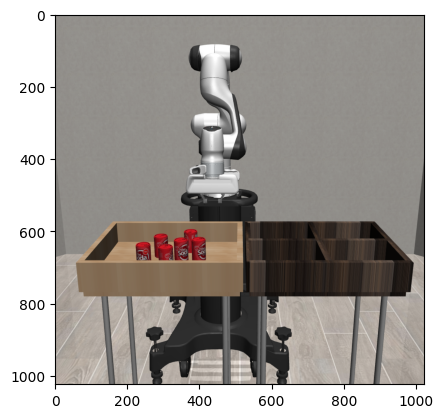

In [246]:
env.sim.set_state_from_flattened(states[0])
env.sim.forward()
for name in ['world', 'robot0_base', 'mount0_base',  'gripper0_eef', 'Milk_main', 'Can_main', "Lemon_main"]:
    with np.printoptions(precision=3, suppress=True):
        print(name, "rotate", xmat2euler(env.sim.data.get_body_xmat(name)))
        print(name, "rotate", quat2euler(env.sim.data.get_body_xquat(name)))
plt.imshow(env.sim.render(camera_name='frontview', height=env_info["camera_heights"], width=env_info["camera_widths"])[::-1, :, :])

In [167]:
milk_xmat = env.sim.data.get_body_xmat("Milk_main").copy()
milk_euler = Rotation.from_matrix(milk_xmat).as_euler("xyz", degrees=True)
can_xmat = env.sim.data.get_body_xmat("Can_main").copy()
can_euler = Rotation.from_matrix(can_xmat).as_euler("xyz", degrees=True)
can_euler, milk_euler

(array([-3.82025049e-02, -2.28018094e-02, -9.70140215e+01]),
 array([-4.97081602e-02, -4.14161377e-03, -1.49976713e+02]))

In [164]:
env.sim.data.get_body_xmat('Milk_main')

array([[-0.86830411,  0.49603223,  0.        ],
       [-0.49603223, -0.86830411,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

In [162]:
milk_xmat

array([[ 1.        , -0.        ,  0.        ],
       [ 0.        ,  0.86830411,  0.49603223],
       [-0.        , -0.49603223,  0.86830411]])

End-effector orientation degree:  [2.16673737 2.18187081 0.09447046]
Can orientation degree:  [0.         0.         2.76723596]
Relative orientation between end-effector and can:  [-2.54126676  1.71902     0.08080213]
Relative orientation between end-effector and can (axis-angle):  [-0.82800723  0.56009901  0.02632732] 175.84853673905323


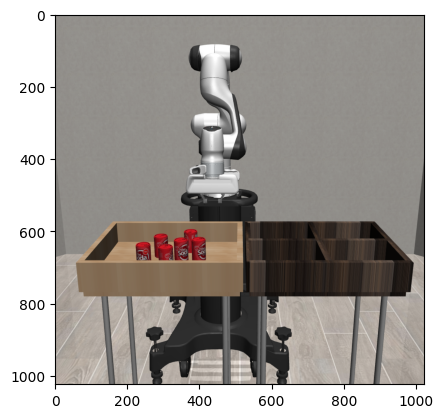

In [248]:
ee_mat = env.sim.data.get_body_xmat('gripper0_eef').copy()
can_mat = env.sim.data.get_body_xmat('Lemon_main').copy()
ee_ang = Rotation.from_matrix(ee_mat).as_rotvec()
can_ang = Rotation.from_matrix(can_mat).as_rotvec()
print("End-effector orientation degree: ", ee_ang)
print("Can orientation degree: ", can_ang)

# Calculate relative orientation
ee_to_can_mat = np.dot(ee_mat.T, can_mat)
ee_to_can_angle = Rotation.from_matrix(ee_to_can_mat).as_rotvec()
print("Relative orientation between end-effector and can: ", ee_to_can_angle)

# Convert relative orientation to axis-angle representation
tolerance = 1e-6
trace = np.trace(ee_to_can_mat)
if trace > 3 - tolerance:
    angle = 0
    axis = np.array([1, 0, 0])
elif trace < -1 + tolerance:
    angle = np.pi
    axis = np.array([ee_to_can_mat[0, 0] + 1,
                     ee_to_can_mat[1, 0],
                     ee_to_can_mat[2, 0]])
    axis = axis / np.linalg.norm(axis)
else:
    angle = np.arccos((trace - 1) / 2)
    axis = np.array([ee_to_can_mat[2, 1] - ee_to_can_mat[1, 2],
                     ee_to_can_mat[0, 2] - ee_to_can_mat[2, 0],
                     ee_to_can_mat[1, 0] - ee_to_can_mat[0, 1]])
    axis = axis / np.linalg.norm(axis)

# Convert angle to degrees
angle_degrees = np.rad2deg(angle)

# Print relative orientation as axis-angle representation
print("Relative orientation between end-effector and can (axis-angle): ", axis, angle_degrees)
plt.imshow(env.sim.render(camera_name='frontview', height=env_info["camera_heights"], width=env_info["camera_widths"])[::-1, :, :])

In [66]:
ee_mat = env.sim.data.get_body_xmat('gripper0_eef')
ee_mat

array([[-0.1789613 ,  0.97517921,  0.1303778 ],
       [ 0.98361051,  0.18029952,  0.00156372],
       [-0.02198215,  0.12852081, -0.99146315]])

In [67]:
can_mat = env.sim.data.get_body_xmat('Milk_main')
can_mat

array([[ 9.99999055e-01,  4.75326723e-04, -1.29032355e-03],
       [-4.77252257e-04,  9.99998773e-01, -1.49239007e-03],
       [ 1.28961260e-03,  1.49300447e-03,  9.99998054e-01]])

In [68]:
# Calculate relative orientation
ee_to_can_mat = np.dot(ee_mat.T, can_mat)

# Convert relative orientation to Euler angles
ee_to_can_euler = np.zeros(3)
ee_to_can_euler[0] = np.arctan2(ee_to_can_mat[2, 1], ee_to_can_mat[2, 2])
ee_to_can_euler[1] = np.arctan2(-ee_to_can_mat[2, 0], np.sqrt(ee_to_can_mat[2, 1]**2 + ee_to_can_mat[2, 2]**2))
ee_to_can_euler[2] = np.arctan2(ee_to_can_mat[1, 0], ee_to_can_mat[0, 0])

# Convert Euler angles to degrees
ee_to_can_euler = np.rad2deg(ee_to_can_euler)

# Print relative orientation as Euler angles
print("Relative orientation between end-effector and can: ", ee_to_can_euler)

Relative orientation between end-effector and can:  [179.99159733  -7.41749092 100.42645878]


In [69]:
ee_to_can_mat

array([[-1.79458911e-01,  9.83491419e-01, -2.32191205e-02],
       [ 9.75257977e-01,  1.80954710e-01,  1.26993190e-01],
       [ 1.29098322e-01,  1.45427099e-04, -9.91631788e-01]])

In [70]:
# Convert relative orientation to axis-angle representation
angle = np.arccos((np.trace(ee_to_can_mat) - 1) / 2)
axis = np.array([ee_to_can_mat[2, 1] - ee_to_can_mat[1, 2],
                 ee_to_can_mat[0, 2] - ee_to_can_mat[2, 0],
                 ee_to_can_mat[1, 0] - ee_to_can_mat[0, 1]])
axis = axis / np.linalg.norm(axis)

# Print relative orientation as axis-angle representation
print("Relative orientation between end-effector and can (axis-angle): ", axis, angle)

Relative orientation between end-effector and can (axis-angle):  [-0.63938461 -0.76776622 -0.04150121] 3.0422340577162017


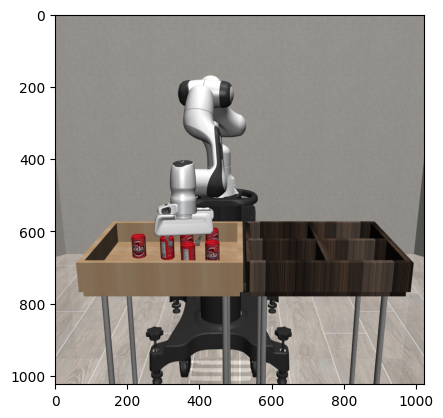

In [71]:
plt.imshow(env.sim.render(camera_name='frontview', height=env_info["camera_heights"], width=env_info["camera_widths"])[::-1, :, :])